Week 6 – Classification Algorithms
Day 1: Setup + Decision Tree Classifier
Dataset: Pima Indians Diabetes (binary classification – diabetic or not) Goal: Build ML workflow — split → train → predict → evaluate, starting with a Decision Tree.

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              confusion_matrix, ConfusionMatrixDisplay, classification_report,
                              roc_curve, roc_auc_score)

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (7, 4)
np.random.seed(42)

Load and Explore the Diabetes Dataset

In [2]:
import pandas as pd

url = "https://raw.githubusercontent.com/plotly/datasets/master/diabetes.csv"
df = pd.read_csv(url)
print("Shape:", df.shape)
df.head()

Shape: (768, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [4]:
print("Class balance (Outcome):")
print(df["Outcome"].value_counts())
print(f"\nPositive (diabetic) rate: {df['Outcome'].mean():.1%}")
print("\nThe dataset is moderately imbalanced (~65% / 35%), which is why we look at")
print("precision/recall/F1 in addition to accuracy, not accuracy alone.")

Class balance (Outcome):
Outcome
0    500
1    268
Name: count, dtype: int64

Positive (diabetic) rate: 34.9%

The dataset is moderately imbalanced (~65% / 35%), which is why we look at
precision/recall/F1 in addition to accuracy, not accuracy alone.


1.1 A data-quality catch: hidden missing values

In [6]:
cols_with_invalid_zero = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]

for col in cols_with_invalid_zero:
    zero_count = (df[col] == 0).sum()
    print(f"{col:15s}: {zero_count:4d} rows with value 0 ({zero_count/len(df):.1%})")

Glucose        :    5 rows with value 0 (0.7%)
BloodPressure  :   35 rows with value 0 (4.6%)
SkinThickness  :  227 rows with value 0 (29.6%)
Insulin        :  374 rows with value 0 (48.7%)
BMI            :   11 rows with value 0 (1.4%)


Visual EDA

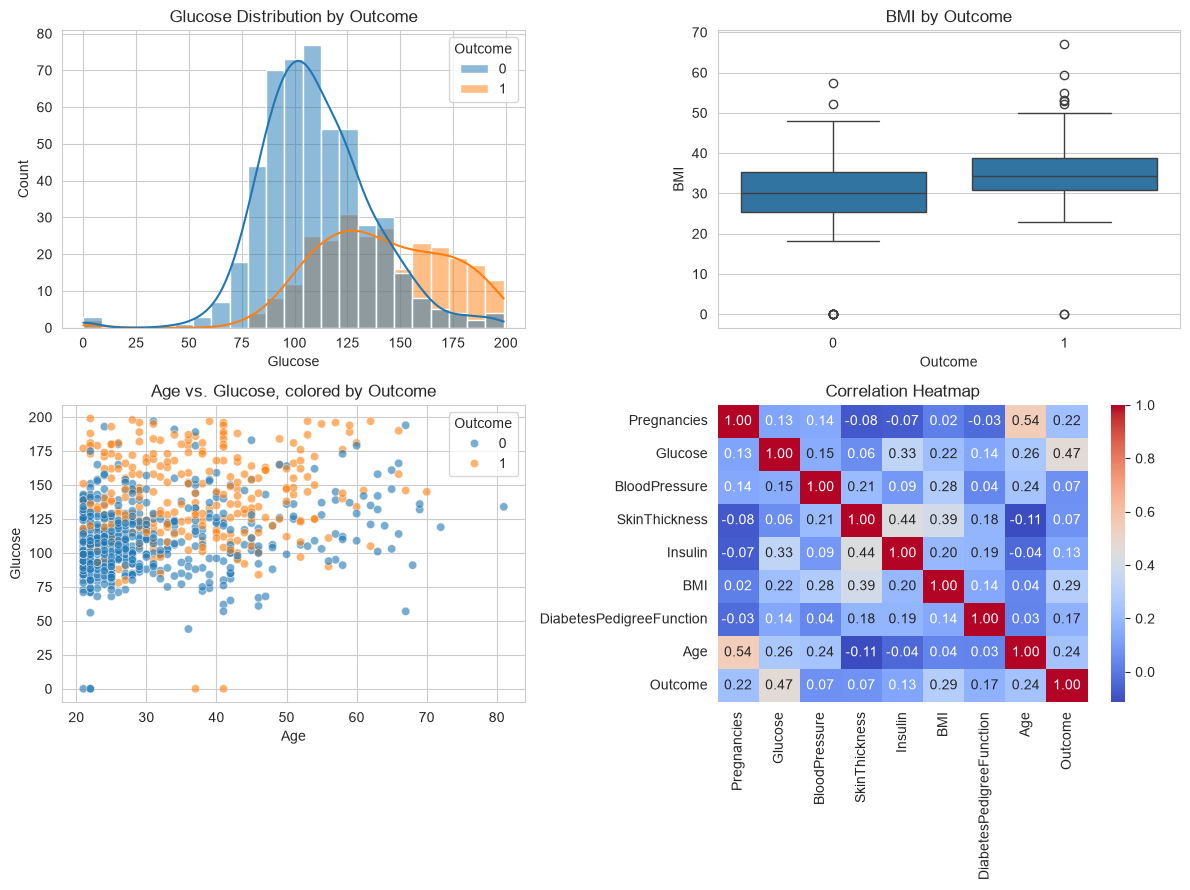

Glucose shows the clearest separation between outcomes -- expected, since it's the most
direct clinical indicator of diabetes.


In [9]:
fig, axes = plt.subplots(2, 2, figsize=(12, 9))

sns.histplot(data=df, x="Glucose", hue="Outcome", kde=True, ax=axes[0, 0])
axes[0, 0].set_title("Glucose Distribution by Outcome")

sns.boxplot(data=df, x="Outcome", y="BMI", ax=axes[0, 1])
axes[0, 1].set_title("BMI by Outcome")

sns.scatterplot(data=df, x="Age", y="Glucose", hue="Outcome", alpha=0.6, ax=axes[1, 0])
axes[1, 0].set_title("Age vs. Glucose, colored by Outcome")

corr = df.corr()
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f", ax=axes[1, 1])
axes[1, 1].set_title("Correlation Heatmap")

plt.tight_layout()
plt.show()

print("Glucose shows the clearest separation between outcomes -- expected, since it's the most")
print("direct clinical indicator of diabetes.")

Part 2 — Cleaning: Fixing the Hidden Zeros

In [10]:
df_clean = df.copy()

for col in cols_with_invalid_zero:
    df_clean[col] = df_clean[col].replace(0, np.nan)

# Impute per-class median so the imputation doesn't blur the signal between classes
for col in cols_with_invalid_zero:
    df_clean[col] = df_clean.groupby("Outcome")[col].transform(lambda x: x.fillna(x.median()))

print("Remaining missing values after cleaning:")
print(df_clean.isnull().sum().sum())
df_clean.head()

Remaining missing values after cleaning:
0


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148.0,72.0,35.0,169.5,33.6,0.627,50,1
1,1,85.0,66.0,29.0,102.5,26.6,0.351,31,0
2,8,183.0,64.0,32.0,169.5,23.3,0.672,32,1
3,1,89.0,66.0,23.0,94.0,28.1,0.167,21,0
4,0,137.0,40.0,35.0,168.0,43.1,2.288,33,1


Part 3 — Train/Test Split

In [11]:
X = df_clean.drop(columns=["Outcome"])
y = df_clean["Outcome"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scale features -- needed for KNN, SVM, and Logistic Regression (distance/gradient based),
# harmless for tree-based models
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Train samples: {len(X_train)}, Test samples: {len(X_test)}")
print(f"Train positive rate: {y_train.mean():.1%}, Test positive rate: {y_test.mean():.1%}")

Train samples: 614, Test samples: 154
Train positive rate: 34.9%, Test positive rate: 35.1%


Part 4 — Train Decision Tree, Random Forest, KNN, SVM (+ Logistic Regression baseline)


Tree-based models (Decision Tree, Random Forest) don't need scaled features, but we use the scaled version for all models here for simplicity and consistency — it doesn't hurt tree models.

In [12]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=2000, random_state=42),
    "Decision Tree": DecisionTreeClassifier(max_depth=5, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=200, max_depth=6, random_state=42),
    "KNN": KNeighborsClassifier(n_neighbors=11),
    "SVM (RBF kernel)": SVC(kernel="rbf", probability=True, random_state=42),
}

trained_models = {}
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    trained_models[name] = model
    print(f"Trained: {name}")

Trained: Logistic Regression
Trained: Decision Tree
Trained: Random Forest
Trained: KNN
Trained: SVM (RBF kernel)


C:\Users\NITRO V5\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


Part 5 — Evaluate and Compare All Models


For each model we compute accuracy, precision, recall, F1-score, and its confusion matrix — exactly the metrics asked for this week.

In [13]:
results = []
predictions = {}
probabilities = {}

for name, model in trained_models.items():
    y_pred = model.predict(X_test_scaled)
    y_proba = model.predict_proba(X_test_scaled)[:, 1]
    predictions[name] = y_pred
    probabilities[name] = y_proba

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_proba),
    })

results_df = pd.DataFrame(results).set_index("Model").round(3)
results_df = results_df.sort_values("F1-score", ascending=False)
results_df

,Accuracy,Precision,Recall,F1-score,ROC-AUC
Model,,,,,
Random Forest,0.864,0.811,0.796,0.804,0.942
SVM (RBF kernel),0.838,0.764,0.778,0.771,0.897
Decision Tree,0.825,0.755,0.741,0.748,0.912
KNN,0.805,0.714,0.741,0.727,0.859
Logistic Regression,0.708,0.588,0.556,0.571,0.826


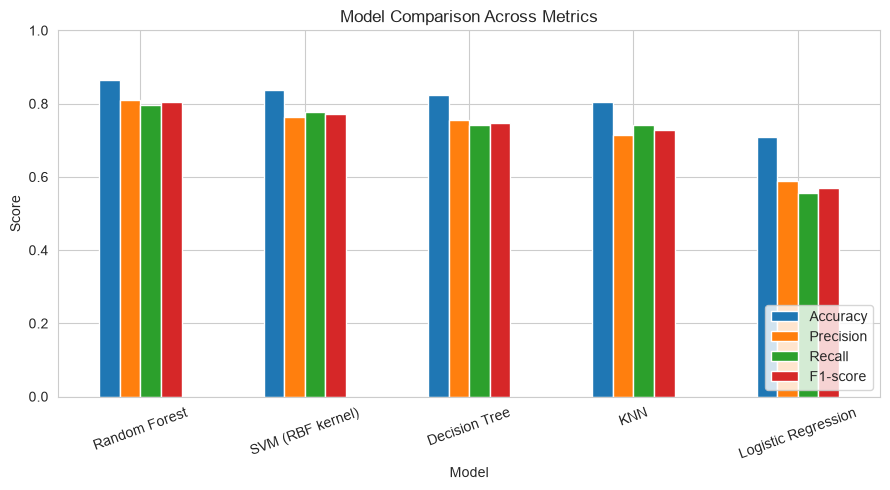

In [14]:
fig, ax = plt.subplots(figsize=(9, 5))
results_df[["Accuracy", "Precision", "Recall", "F1-score"]].plot(kind="bar", ax=ax)
ax.set_title("Model Comparison Across Metrics")
ax.set_ylabel("Score")
ax.set_ylim(0, 1)
ax.legend(loc="lower right")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

5.1 Confusion matrices for every model

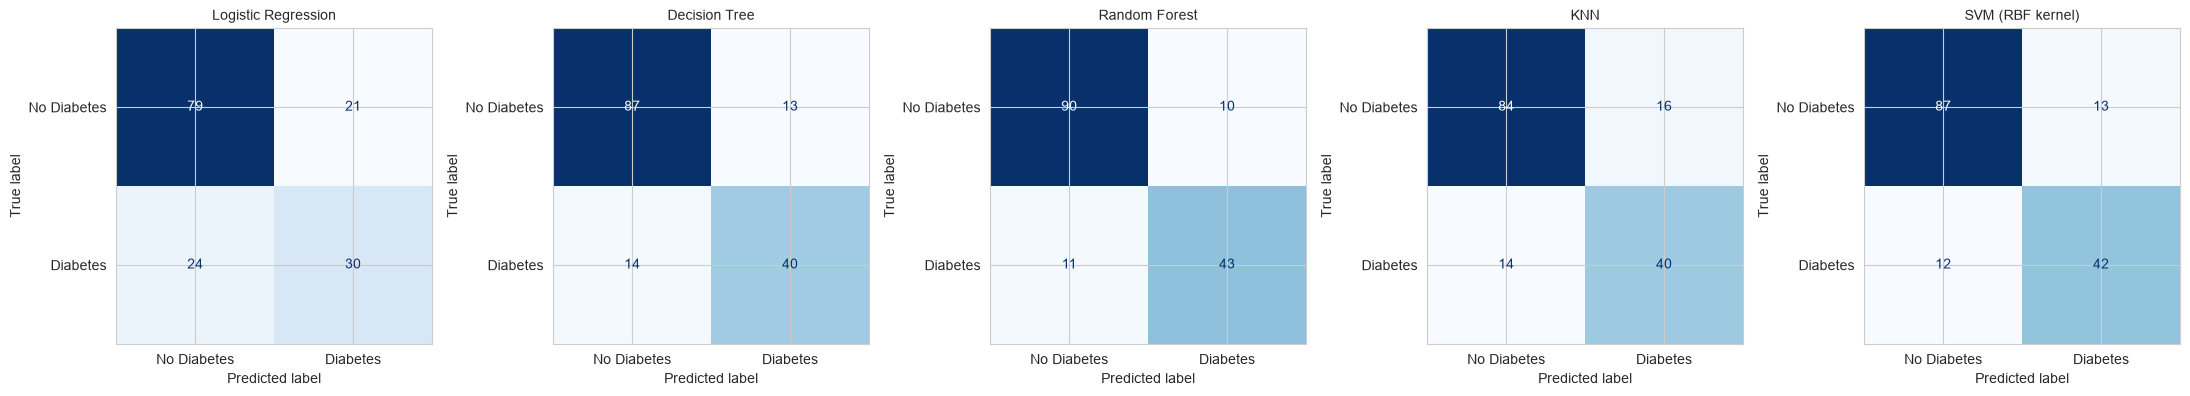

In [15]:
fig, axes = plt.subplots(1, 5, figsize=(22, 4.5))

for ax, (name, y_pred) in zip(axes, predictions.items()):
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No Diabetes", "Diabetes"])
    disp.plot(ax=ax, colorbar=False, cmap="Blues", values_format="d")
    ax.set_title(name, fontsize=10)

plt.tight_layout()
plt.show()


5.2 ROC curves for every model

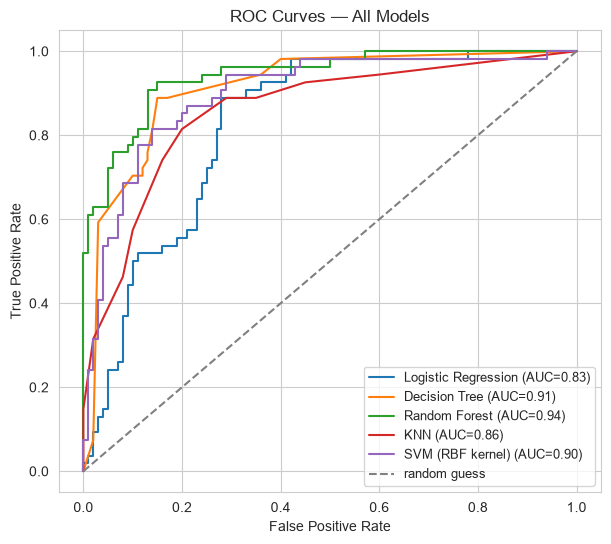

In [16]:
fig, ax = plt.subplots(figsize=(7, 6))

for name, y_proba in probabilities.items():
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)
    ax.plot(fpr, tpr, label=f"{name} (AUC={auc:.2f})")

ax.plot([0, 1], [0, 1], linestyle="--", color="grey", label="random guess")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curves — All Models")
ax.legend(loc="lower right", fontsize=9)
plt.show()

5.3 A closer look at the best model's mistakes

In [17]:
best_model_name = results_df.index[0]
print(f"Best model by F1-score: {best_model_name}\n")
print(classification_report(y_test, predictions[best_model_name],
                             target_names=["No Diabetes", "Diabetes"]))

Best model by F1-score: Random Forest

              precision    recall  f1-score   support

 No Diabetes       0.89      0.90      0.90       100
    Diabetes       0.81      0.80      0.80        54

    accuracy                           0.86       154
   macro avg       0.85      0.85      0.85       154
weighted avg       0.86      0.86      0.86       154



Part 6 — What drives the predictions? (Random Forest feature importance)

C:\Users\NITRO V5\AppData\Local\Temp\ipykernel_230704\2285219878.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances.values, y=importances.index, ax=ax, palette="viridis")


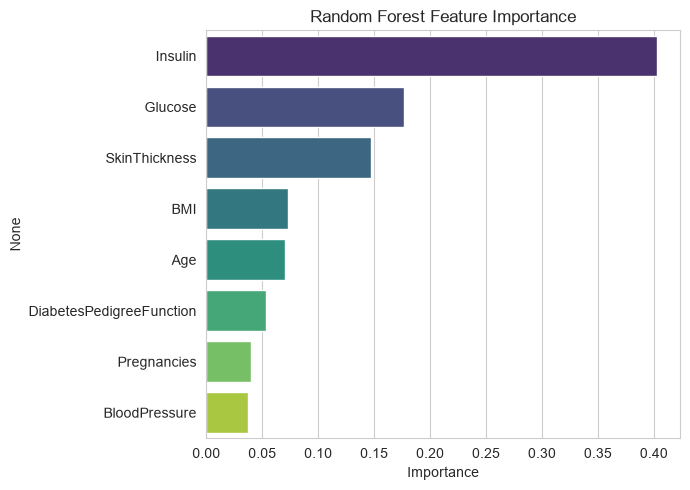

Insulin                     0.403
Glucose                     0.176
SkinThickness               0.147
BMI                         0.073
Age                         0.070
DiabetesPedigreeFunction    0.053
Pregnancies                 0.040
BloodPressure               0.037
dtype: float64


In [18]:
rf_model = trained_models["Random Forest"]
importances = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(7, 5))
sns.barplot(x=importances.values, y=importances.index, ax=ax, palette="viridis")
ax.set_title("Random Forest Feature Importance")
ax.set_xlabel("Importance")
plt.tight_layout()
plt.show()

print(importances.round(3))

6.1 One Decision Tree, visualized

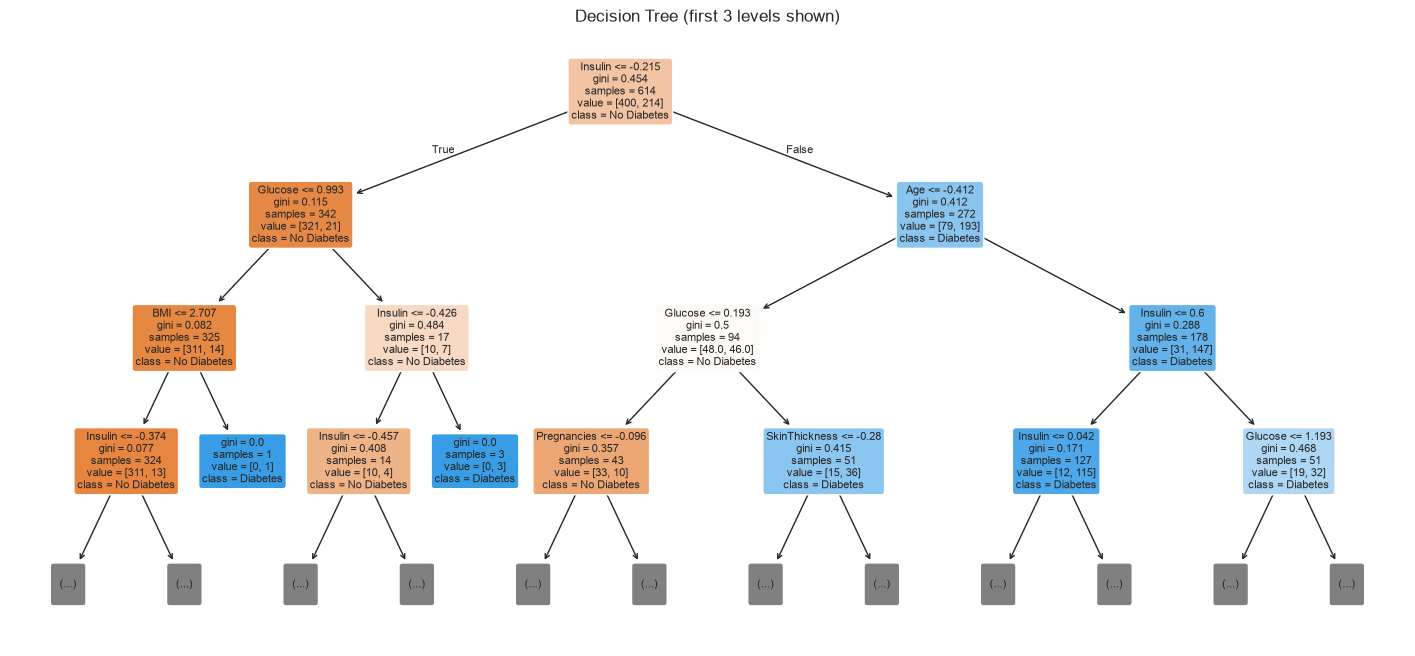

In [19]:
fig, ax = plt.subplots(figsize=(18, 8))
plot_tree(trained_models["Decision Tree"], feature_names=X.columns, class_names=["No Diabetes", "Diabetes"],
          filled=True, rounded=True, fontsize=8, max_depth=3, ax=ax)
plt.title("Decision Tree (first 3 levels shown)")
plt.show()

Part 7 — Summary Table and Final Recommendation

In [20]:
print("Final comparison table (sorted by F1-score):\n")
results_df

Final comparison table (sorted by F1-score):



,Accuracy,Precision,Recall,F1-score,ROC-AUC
Model,,,,,
Random Forest,0.864,0.811,0.796,0.804,0.942
SVM (RBF kernel),0.838,0.764,0.778,0.771,0.897
Decision Tree,0.825,0.755,0.741,0.748,0.912
KNN,0.805,0.714,0.741,0.727,0.859
Logistic Regression,0.708,0.588,0.556,0.571,0.826
